In [3]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))


In [6]:
from tensorflow.keras.utils import to_categorical  # 분류분석시 원핫인코딩
from tensorflow.keras.models import Sequential # 모델생성
from tensorflow.keras.layers import Dense, Input
import numpy as np

# 머신러닝/딥러닝 : 데이터의 법칙성을 추출
- 다양한 분야에서 응용 : 글씨 인식, 문장분류, 질병진단, (얼굴인식)...
- ML/DL의 종류
    - 지도학습(독립=입력변수와 종속=타겟=출력변수가 모두 주어졌을 경우)
        - 회귀분석(타겟변수가 연속형) vs 분류분석(multi, binary)
    - 비지도학습(입력변수만)
        -군집분석(군집화)
    - 강화학습

※ 지도학습에서의 ML, DL 프로그램 방식
1. 데이터셋 확보(input=입력변수, target=종속변수)
    원본 데이터 및 시뮬레이션을 통해 데이터 생성
2. 전처리
    스케일 조정
    훈련셋(학습셋), 검증셋, 시험셋(테스트셋) = 6: 2: 2 or 7: 2: 1 or 8 : 0 : 2
    학습 및 평가 가능한 포맷으로 변환(*numpy*, DataFrame)
3. 모델 구성
    Seqouetial 객체 생성 뒤 필요한 층을 add()함수로 추가
4. 모델 학습과정 설정
    copile() 함수 이용. 손실함수, optimizer, metrics(평가지표)
5. 모델학습시키기 (ft. 학습과정 지켜보기)
    fit() 함수 이용 - 훈련셋입력 = 독립변수, 훈련셋타겟 = 종속변수, 학습횟수, 검증셋
6. 모델 평가
    시험셋(테스트셋)을 인자로 넣은 evaluate()함수 이용, 그래프

# 1. 데이터셋 생성

In [7]:
# 학습데이터 = 훈련데이터
x_train = np.array([1,2,3,4,5,6,7,8,9]*10)
y_train = np.array([2,4,6,8,10,12,14,16,18]*10)


# 검증데이터
x_val = np.array([1,2,3,4,5,6,7,8,9])
y_val = np.array([2,4,6,8,10,12,14,16,18])

# 시험데이터 = 테스트셋
x_test = np.array([1,2,3,4,5,6,7,8,9])
y_test = np.array([2,4,6,8,10,12,14,16,18])
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((90,), (90,), (9,), (9,), (9,), (9,))

# 2. 데이터 전처리

In [4]:
# 인코딩 종류
data = np.array(['서울', '경기', '인천', '부산'])
print('원 데이터:', data)
from sklearn.preprocessing import LabelEncoder  # 특정한 문자를 숫자로 인코딩해줌
le = LabelEncoder()
# le.fit(data)
# labled_data = le.transform(data)
# 위 둘을 한번에 할 수 있다 -> le.fit_transform
labled_data = le.fit_transform(data)
print('라벨인코딩된 데이터 :', labled_data)
one_hot_encoded_data = to_categorical(labled_data)
print('원핫인코딩된 데이터 :', one_hot_encoded_data)

원 데이터: ['서울' '경기' '인천' '부산']
라벨인코딩된 데이터 : [2 0 3 1]
원핫인코딩된 데이터 : [[0. 0. 1. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]]


In [5]:
# 분류분석을 위해, target을 원핫인코딩(리벨링 전환)

import pandas as pd
data = np.array([1,2,2,4,2])

categorical_one_hot = to_categorical(data)
print('to_categorical을 이용한 원핫인코딩 :\n', categorical_one_hot)

get_dumies_one_hot = pd.get_dummies(data)
display('get_dumies를 이용한 원핫인코딩 :', get_dumies_one_hot)

print(type(categorical_one_hot))
print(type(get_dumies_one_hot))

to_categorical을 이용한 원핫인코딩 :
 [[0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]]


'get_dumies를 이용한 원핫인코딩 :'

,1,2,4
0,1,0,0
1,0,1,0
2,0,1,0
3,0,0,1
4,0,1,0


<class 'numpy.ndarray'>
<class 'pandas.core.frame.DataFrame'>


In [7]:
y_train, Y_train, y_train.shape, Y_train.shape

(array([ 2,  4,  6,  8, 10, 12, 14, 16, 18,  2,  4,  6,  8, 10, 12, 14, 16,
        18,  2,  4,  6,  8, 10, 12, 14, 16, 18,  2,  4,  6,  8, 10, 12, 14,
        16, 18,  2,  4,  6,  8, 10, 12, 14, 16, 18,  2,  4,  6,  8, 10, 12,
        14, 16, 18,  2,  4,  6,  8, 10, 12, 14, 16, 18,  2,  4,  6,  8, 10,
        12, 14, 16, 18,  2,  4,  6,  8, 10, 12, 14, 16, 18,  2,  4,  6,  8,
        10, 12, 14, 16, 18]),
 array([[0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 0.],
        [0., 0., 0., ..., 0., 0., 1.]], dtype=float32),
 (90,),
 (90, 19))

In [9]:
# 분류분석을 위한 target변수 라벨링 전환(=원핫인코딩)
Y_train = to_categorical(y_train)
Y_val = to_categorical(y_val)
Y_test = to_categorical(y_test)

In [10]:
print('훈련셋 구조:', x_train.shape, Y_train.shape) # 독립변수 1개, 타겟변수 19개
print('검증셋 구조:', x_val.shape, Y_val.shape)
print('테스트셋 구조:', x_test.shape, Y_test.shape)

훈련셋 구조: (90,) (90, 19)
검증셋 구조: (9,) (9, 19)
테스트셋 구조: (9,) (9, 19)


# 3. 모델 구성하기

In [11]:
model = Sequential()
model.add(Input(shape=(1,))) #입력층
model.add(Dense(units=38, activation='sigmoid')) # units은 출력수, 활성화 함수 : relu, tanh, sigmoid..
model.add(Dense(units=64, activation='elu'))
model.add(Dense(units=32, activation='elu'))
model.add(Dense(units=19, activation='softmax'))  
# 'softmax' : 모든 출력 결과의 합이 1. 분류분석 마지막 레이어(출력층)에서 활성화함수로 사용

In [12]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


# 4. 모델 학습과정 설정

In [13]:
model.compile(loss="categorical_crossentropy", # 분류분석에서의 손실함수(원핫인코딩有)
             optimizer='sgd',
             metrics=['accuracy'])

# 5. 모델 학습시키기

In [14]:
%%time
hist = model.fit(x_train, Y_train,
                epochs=300,
                batch_size=10,
                verbose=2, # 0: 출력없음, 1:기본값, 2:에포크별 상세출력
                validation_data= (x_val, Y_val) # 튜플 혹은 리스트 둘다 가능
                )

Epoch 1/300
9/9 - 1s - loss: 3.0301 - accuracy: 0.0000e+00 - val_loss: 2.9672 - val_accuracy: 0.0000e+00 - 701ms/epoch - 78ms/step
Epoch 2/300
9/9 - 0s - loss: 2.9388 - accuracy: 0.0333 - val_loss: 2.8858 - val_accuracy: 0.0000e+00 - 50ms/epoch - 6ms/step
Epoch 3/300
9/9 - 0s - loss: 2.8644 - accuracy: 0.0000e+00 - val_loss: 2.8177 - val_accuracy: 0.1111 - 59ms/epoch - 7ms/step
Epoch 4/300
9/9 - 0s - loss: 2.8003 - accuracy: 0.1111 - val_loss: 2.7576 - val_accuracy: 0.1111 - 68ms/epoch - 8ms/step
Epoch 5/300
9/9 - 0s - loss: 2.7395 - accuracy: 0.0889 - val_loss: 2.7024 - val_accuracy: 0.1111 - 89ms/epoch - 10ms/step
Epoch 6/300
9/9 - 0s - loss: 2.6878 - accuracy: 0.1111 - val_loss: 2.6511 - val_accuracy: 0.1111 - 71ms/epoch - 8ms/step
Epoch 7/300
9/9 - 0s - loss: 2.6410 - accuracy: 0.0778 - val_loss: 2.6033 - val_accuracy: 0.1111 - 66ms/epoch - 7ms/step
Epoch 8/300
9/9 - 0s - loss: 2.5933 - accuracy: 0.0889 - val_loss: 2.5580 - val_accuracy: 0.1111 - 73ms/epoch - 8ms/step
Epoch 9/300
9

9/9 - 0s - loss: 1.4839 - accuracy: 0.4778 - val_loss: 1.4544 - val_accuracy: 0.5556 - 43ms/epoch - 5ms/step
Epoch 69/300
9/9 - 0s - loss: 1.4737 - accuracy: 0.5333 - val_loss: 1.4439 - val_accuracy: 0.5556 - 42ms/epoch - 5ms/step
Epoch 70/300
9/9 - 0s - loss: 1.4674 - accuracy: 0.5556 - val_loss: 1.4340 - val_accuracy: 0.5556 - 44ms/epoch - 5ms/step
Epoch 71/300
9/9 - 0s - loss: 1.4454 - accuracy: 0.4778 - val_loss: 1.4239 - val_accuracy: 0.5556 - 49ms/epoch - 5ms/step
Epoch 72/300
9/9 - 0s - loss: 1.4497 - accuracy: 0.5222 - val_loss: 1.4145 - val_accuracy: 0.6667 - 39ms/epoch - 4ms/step
Epoch 73/300
9/9 - 0s - loss: 1.4315 - accuracy: 0.5333 - val_loss: 1.4050 - val_accuracy: 0.5556 - 43ms/epoch - 5ms/step
Epoch 74/300
9/9 - 0s - loss: 1.4189 - accuracy: 0.5444 - val_loss: 1.3966 - val_accuracy: 0.6667 - 40ms/epoch - 4ms/step
Epoch 75/300
9/9 - 0s - loss: 1.4144 - accuracy: 0.5667 - val_loss: 1.3870 - val_accuracy: 0.6667 - 48ms/epoch - 5ms/step
Epoch 76/300
9/9 - 0s - loss: 1.4004 

Epoch 135/300
9/9 - 0s - loss: 1.0039 - accuracy: 0.8333 - val_loss: 0.9740 - val_accuracy: 1.0000 - 56ms/epoch - 6ms/step
Epoch 136/300
9/9 - 0s - loss: 1.0083 - accuracy: 0.8444 - val_loss: 0.9691 - val_accuracy: 0.8889 - 46ms/epoch - 5ms/step
Epoch 137/300
9/9 - 0s - loss: 0.9994 - accuracy: 0.8111 - val_loss: 0.9651 - val_accuracy: 0.8889 - 43ms/epoch - 5ms/step
Epoch 138/300
9/9 - 0s - loss: 0.9803 - accuracy: 0.8444 - val_loss: 0.9565 - val_accuracy: 0.7778 - 49ms/epoch - 5ms/step
Epoch 139/300
9/9 - 0s - loss: 0.9826 - accuracy: 0.8000 - val_loss: 0.9517 - val_accuracy: 0.8889 - 41ms/epoch - 5ms/step
Epoch 140/300
9/9 - 0s - loss: 0.9856 - accuracy: 0.8667 - val_loss: 0.9462 - val_accuracy: 0.7778 - 68ms/epoch - 8ms/step
Epoch 141/300
9/9 - 0s - loss: 0.9701 - accuracy: 0.8222 - val_loss: 0.9454 - val_accuracy: 1.0000 - 37ms/epoch - 4ms/step
Epoch 142/300
9/9 - 0s - loss: 0.9696 - accuracy: 0.7667 - val_loss: 0.9367 - val_accuracy: 0.8889 - 48ms/epoch - 5ms/step
Epoch 143/300
9/

Epoch 202/300
9/9 - 0s - loss: 0.7291 - accuracy: 0.9222 - val_loss: 0.6908 - val_accuracy: 0.8889 - 51ms/epoch - 6ms/step
Epoch 203/300
9/9 - 0s - loss: 0.7267 - accuracy: 0.8444 - val_loss: 0.6928 - val_accuracy: 0.8889 - 56ms/epoch - 6ms/step
Epoch 204/300
9/9 - 0s - loss: 0.7144 - accuracy: 0.8222 - val_loss: 0.6817 - val_accuracy: 0.8889 - 53ms/epoch - 6ms/step
Epoch 205/300
9/9 - 0s - loss: 0.7015 - accuracy: 0.9444 - val_loss: 0.6730 - val_accuracy: 1.0000 - 427ms/epoch - 47ms/step
Epoch 206/300
9/9 - 0s - loss: 0.7137 - accuracy: 0.9111 - val_loss: 0.6720 - val_accuracy: 1.0000 - 60ms/epoch - 7ms/step
Epoch 207/300
9/9 - 0s - loss: 0.6869 - accuracy: 0.9889 - val_loss: 0.6705 - val_accuracy: 0.8889 - 75ms/epoch - 8ms/step
Epoch 208/300
9/9 - 0s - loss: 0.6922 - accuracy: 0.9444 - val_loss: 0.6757 - val_accuracy: 0.8889 - 120ms/epoch - 13ms/step
Epoch 209/300
9/9 - 0s - loss: 0.7004 - accuracy: 0.8889 - val_loss: 0.6702 - val_accuracy: 0.8889 - 55ms/epoch - 6ms/step
Epoch 210/30

Epoch 269/300
9/9 - 0s - loss: 0.4999 - accuracy: 1.0000 - val_loss: 0.4831 - val_accuracy: 1.0000 - 127ms/epoch - 14ms/step
Epoch 270/300
9/9 - 0s - loss: 0.4933 - accuracy: 0.9444 - val_loss: 0.4992 - val_accuracy: 0.8889 - 108ms/epoch - 12ms/step
Epoch 271/300
9/9 - 0s - loss: 0.5124 - accuracy: 0.9667 - val_loss: 0.4740 - val_accuracy: 1.0000 - 52ms/epoch - 6ms/step
Epoch 272/300
9/9 - 0s - loss: 0.5101 - accuracy: 0.9444 - val_loss: 0.4715 - val_accuracy: 1.0000 - 67ms/epoch - 7ms/step
Epoch 273/300
9/9 - 0s - loss: 0.5138 - accuracy: 0.9556 - val_loss: 0.4661 - val_accuracy: 1.0000 - 197ms/epoch - 22ms/step
Epoch 274/300
9/9 - 0s - loss: 0.4897 - accuracy: 0.9889 - val_loss: 0.4732 - val_accuracy: 1.0000 - 62ms/epoch - 7ms/step
Epoch 275/300
9/9 - 0s - loss: 0.5038 - accuracy: 0.9556 - val_loss: 0.4614 - val_accuracy: 1.0000 - 62ms/epoch - 7ms/step
Epoch 276/300
9/9 - 0s - loss: 0.4815 - accuracy: 0.9667 - val_loss: 0.4815 - val_accuracy: 0.8889 - 119ms/epoch - 13ms/step
Epoch 27

# 6. 모델평가하기(모델학습과정 살펴보고, evaluate)

In [15]:
hist.history

{'loss': [3.0301473140716553,
  2.9387784004211426,
  2.864427328109741,
  2.8003218173980713,
  2.7395436763763428,
  2.6877942085266113,
  2.641042470932007,
  2.59328031539917,
  2.5494160652160645,
  2.505310535430908,
  2.466649055480957,
  2.4271209239959717,
  2.3948309421539307,
  2.360016107559204,
  2.3284924030303955,
  2.3027584552764893,
  2.2721853256225586,
  2.2476651668548584,
  2.2235147953033447,
  2.193617105484009,
  2.1741418838500977,
  2.150200128555298,
  2.1287851333618164,
  2.1092352867126465,
  2.0899057388305664,
  2.068075656890869,
  2.0535597801208496,
  2.030604839324951,
  2.017423152923584,
  1.9966939687728882,
  1.9828097820281982,
  1.963247299194336,
  1.950133204460144,
  1.930118441581726,
  1.9164750576019287,
  1.8953282833099365,
  1.8842003345489502,
  1.8724477291107178,
  1.8527886867523193,
  1.8352563381195068,
  1.8156846761703491,
  1.8028613328933716,
  1.7956271171569824,
  1.7722783088684082,
  1.7617332935333252,
  1.7461476325988

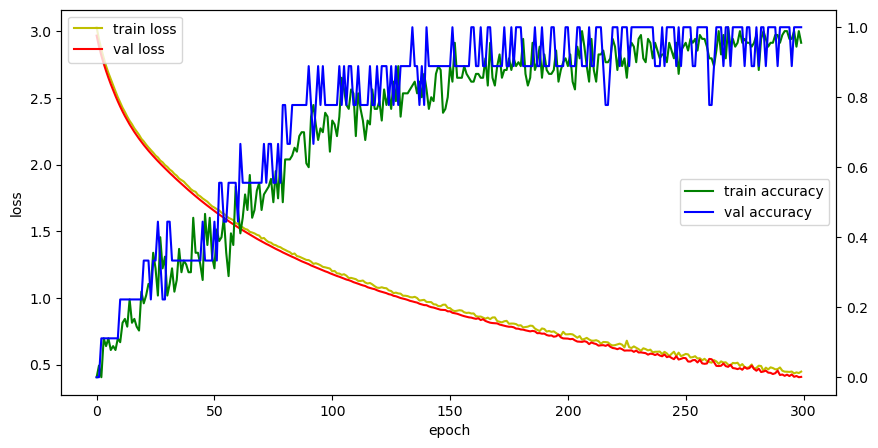

In [17]:
# 모델학습 과정 시각화
import matplotlib.pyplot as plt
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')

acc_ax = loss_ax.twinx() # loss_x와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
loss_ax.legend(loc='upper left')
acc_ax.legend(loc='center right')
plt.show()

In [18]:
# 모델평가
score = model.evaluate(x_test, Y_test,
                      batch_size=1)

9/9 [==============================] - 0s 2ms/step - loss: 0.4078 - accuracy: 1.0000


In [19]:
score # loss, accuracy

[0.407840371131897, 1.0]

In [20]:
print('평가된 loss :', score[0])
print('평가된 accuracy :', score[1]*100, '%')

평가된 loss : 0.407840371131897
평가된 accuracy : 100.0 %


# 7. 모델 사용하기

In [21]:
H = model.predict(np.array([[2]]))
H

1/1 [==============================] - 0s 150ms/step


array([[1.20908681e-13, 5.27408982e-16, 8.62079114e-02, 7.02178997e-14,
        8.04715216e-01, 7.41678583e-14, 1.08006507e-01, 1.11324450e-10,
        1.06866448e-03, 1.36246624e-12, 1.76145170e-06, 2.44504769e-16,
        2.08567413e-10, 1.05720845e-13, 2.97584951e-15, 2.68900562e-11,
        1.96489436e-20, 1.71529552e-13, 6.54412025e-28]], dtype=float32)

In [22]:
# 분류분석의 예측은 predict 결과를 argmax()
model.predict(np.array([[2]])).argmax() # 가장 높은 확률의 인덱스 반환

1/1 [==============================] - 0s 28ms/step


4

In [23]:
# 4를 몇%로 예측했는지
H[0, H.argmax()]*100

80.47152161598206

# 8. 모델 저장하기

In [24]:
#model.save('model/02_deep.h5')  # tensorflow 10.5 이전 버전에서만 사용 가능
from tensorflow.keras.models import save_model  # tensorflow 모든 버전 사용가능
save_model(model, 'model/02_deep.h5')

## 저장된 모델 사용하기

In [4]:
from tensorflow.keras.models import load_model
model2 = load_model('model/02_deep.h5')

In [10]:
H2 = model2.predict(np.array([[4]]))

1/1 [==============================] - 0s 21ms/step


In [13]:
H2.argmax(), round(H2[0, H2.argmax()]*100,2)

(8, 60.65)

In [15]:
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 38)                76        
                                                                 
 dense_1 (Dense)             (None, 64)                2496      
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 19)                627       
                                                                 
Total params: 5,279
Trainable params: 5,279
Non-trainable params: 0
_________________________________________________________________


In [21]:
data = np.array([[2],
                 [3]])
predictions = model2.predict(data)
predictions.argmax(axis=1)

1/1 [==============================] - 0s 22ms/step


array([4, 6], dtype=int64)

In [27]:
def predict_classes(model, data):
    predictions = model.predict(data)
    return predictions.argmax(axis = -1)

In [29]:
input_data = int(input('어떤데이터를 예측할까요? '))
data = np.array([[input_data]])
%time
print('예측된 분류는', predict_classes(model2, data))

어떤데이터를 예측할까요? 5
CPU times: total: 0 ns
Wall time: 0 ns
1/1 [==============================] - 0s 21ms/step
예측된 분류는 [10]


In [30]:
import tensorflow as tf
@tf.function(reduce_retracing=True)
def predict_classes2(model, data):
    predictions = model(data, training=False)
    return tf.argmax(predictions, axis = -1)

In [31]:
input_data = int(input('어떤데이터를 예측할까요? '))
data = np.array([[input_data]])
%time
print('예측된 분류는', predict_classes2(model2, data))

어떤데이터를 예측할까요? 10
CPU times: total: 0 ns
Wall time: 0 ns
예측된 분류는 tf.Tensor([18], shape=(1,), dtype=int64)
